In [477]:
import pandas
import pandas as pd
import seaborn as sbn
import sys
import matplotlib.pyplot as plt


# show all elements of a dataframe
# pandas.set_option("display.max_rows", None)
pandas.set_option("display.max_columns", None)


sys.path.append("../../src/")

In [478]:
from distribution_utility import show_hist_and_box_plot
from distribution_utility import calculate_outlier_bounds
from distribution_utility import compare_distributions_consistent
from distribution_utility import compare_box_plots
from distribution_utility import check_all_outliers
from outliers_detection_utility import analyze_outliers

In [479]:
races = pd.read_csv('../../dataset/preprocessedRaces.csv', sep=",")
races.head()

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,date,climb/length,median_delta,std_delta
0,tour-de-france/1978/stage-6,Tour de France,100,NaN,162000,1101,1,1241,NaN,1,0,0,1978-07-05,0.006796,27.0,6.847590
1,vuelta-a-espana/2016/stage-14,Vuelta a España,80,100.0,196000,5575,5,821,NaN,1,0,0,2016-09-03,0.028444,1957.0,873.835670
2,tour-de-france/2019/stage-21,Tour de France,100,120.0,128000,781,1,1699,NaN,1,0,0,2019-07-28,0.006102,29.0,44.079531
3,volta-a-catalunya/1999/prologue,Volta Ciclista a Catalunya,50,NaN,8100,68,1,804,NaN,1,0,0,1999-06-17,0.008395,53.0,27.154498
4,tour-de-france/2022/stage-9,Tour de France,100,120.0,192900,3743,3,1551,24.0,1,0,0,2022-07-10,0.019404,1376.0,675.354230


In [480]:
races.isna().sum()

_url                      0
name                      0
points                    0
uci_points             3682
length                    0
climb_total               0
profile                   0
startlist_quality         0
average_temperature    5076
is_tarmac                 0
is_cobbled                0
is_gravel                 0
date                      0
climb/length              0
median_delta              0
std_delta                 0
dtype: int64

In [481]:
races.dtypes

_url                    object
name                    object
points                   int64
uci_points             float64
length                   int64
climb_total              int64
profile                  int64
startlist_quality        int64
average_temperature    float64
is_tarmac                int64
is_cobbled               int64
is_gravel                int64
date                    object
climb/length           float64
median_delta           float64
std_delta              float64
dtype: object

In [482]:
cyclists = pd.read_csv('../../dataset/preprocessedCyclists.csv', sep=",")
cyclists.head()

,name,BMI,median position,AVG position,# cyclist races,nationality,continent,geo area,birth_year,AVG weighted position,AVG position Autumn,AVG position Spring,AVG position Summer,AVG position Winter,AVG position Q1,AVG position Q2,AVG position Q3,AVG position Q4,std_dev position
0,sean-kelly,23.770000,6,16,629,Ireland,Europe,Northern Europe,1956.0,22,11.0,7.0,22.0,20.0,8.0,10.0,23.0,18.0,24.497844
1,gerrie-knetemann,19.959003,38,48,271,Netherlands,Europe,Western Europe,1951.0,66,56.0,15.0,58.0,NaN,15.0,18.0,66.0,NaN,46.993017
2,rene-bittinger,22.790000,42,47,146,France,Europe,Western Europe,1954.0,54,15.0,31.0,55.0,NaN,17.0,37.0,56.0,18.0,32.648452
3,joseph-bruyere,23.086015,8,16,48,Belgium,Europe,Western Europe,1948.0,21,29.0,11.0,19.0,NaN,5.0,14.0,23.0,NaN,19.723611
4,sven-ake-nilsson,21.300000,25,33,145,Sweden,Europe,Northern Europe,1951.0,38,17.0,12.0,38.0,NaN,14.0,27.0,37.0,16.0,26.276978


In [483]:
cyclists.isna().sum()

name                        0
BMI                         0
median position             0
AVG position                0
# cyclist races             0
nationality                 0
continent                   0
geo area                    0
birth_year                  0
AVG weighted position       0
AVG position Autumn      2879
AVG position Spring       737
AVG position Summer      1945
AVG position Winter      4523
AVG position Q1          1694
AVG position Q2          1023
AVG position Q3          2280
AVG position Q4          4270
std_dev position            0
dtype: int64

In [484]:
cyclists.dtypes

name                      object
BMI                      float64
median position            int64
AVG position               int64
# cyclist races            int64
nationality               object
continent                 object
geo area                  object
birth_year               float64
AVG weighted position      int64
AVG position Autumn      float64
AVG position Spring      float64
AVG position Summer      float64
AVG position Winter      float64
AVG position Q1          float64
AVG position Q2          float64
AVG position Q3          float64
AVG position Q4          float64
std_dev position         float64
dtype: object

# Outliers Detection for cyclists

Feature selection based on NAN values and high correlation

In [485]:
numeric_columns = ['BMI', 'median position', 'std_dev position', '# cyclist races', 'birth_year']
numeric_cyclists_df = cyclists[numeric_columns]
numeric_cyclists_df

,BMI,median position,std_dev position,# cyclist races,birth_year
0,23.770000,6,24.497844,629,1956.0
1,19.959003,38,46.993017,271,1951.0
2,22.790000,42,32.648452,146,1954.0
3,23.086015,8,19.723611,48,1948.0
4,21.300000,25,26.276978,145,1951.0
...,...,...,...,...,...
6090,19.696783,173,0.000000,1,1969.0
6091,20.031931,17,0.000000,1,1965.0
6092,25.450000,54,0.000000,1,1992.0
6093,20.011635,38,0.000000,1,1948.0


,BMI,median position,std_dev position,# cyclist races,birth_year
BMI,1.000000,0.007206,0.048828,-0.022857,-0.134499
median position,0.007206,1.000000,0.258890,-0.080105,0.486306
std_dev position,0.048828,0.258890,1.000000,0.356324,0.248989
# cyclist races,-0.022857,-0.080105,0.356324,1.000000,0.161916
birth_year,-0.134499,0.486306,0.248989,0.161916,1.000000


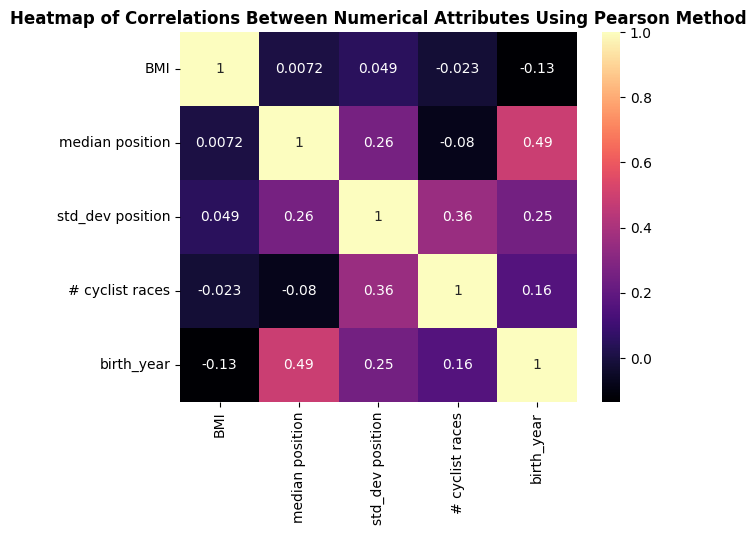

In [486]:
pearson_matrix = numeric_cyclists_df.corr(method='pearson')
display(pearson_matrix)
sbn.heatmap(pearson_matrix, annot=True, cmap="magma")
plt.title("Heatmap of Correlations Between Numerical Attributes Using Pearson Method", fontweight='bold')
plt.show()
plt.close()

We will now display the distributions of the selected columns and address the most extreme outliers based on these initial distributions, essentially taking a snapshot of the initial state of the dataframe _cyclists_. We will not adopt a cumulative approach, where the removal of outliers from one column would affect the subsequent distributions of the other columns

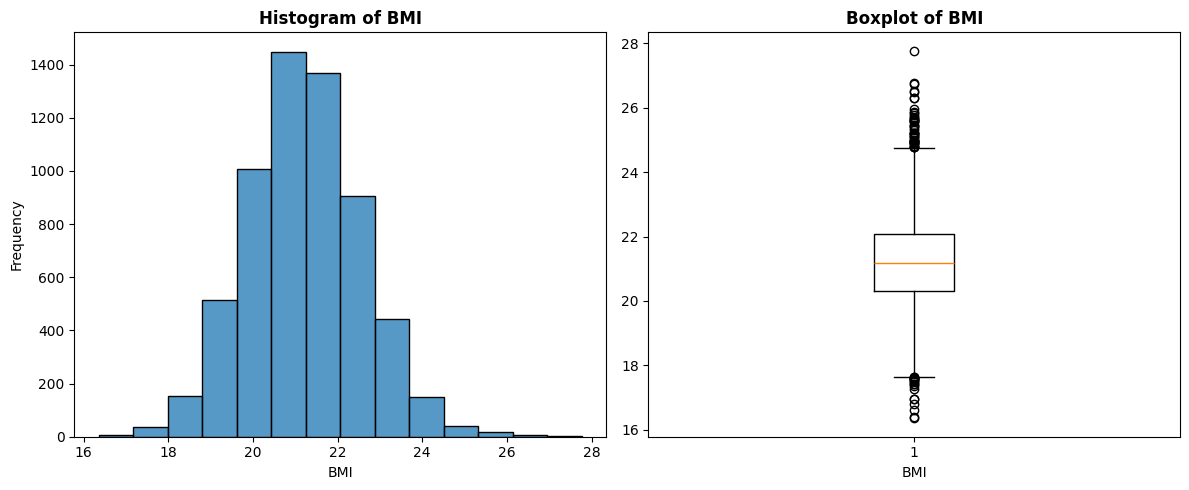

Outliers in BMI: [np.float64(25.20022254995826), np.float64(26.49), np.float64(26.78), np.float64(26.3), np.float64(24.807923763767764), np.float64(25.36941027818859), np.float64(27.77), np.float64(26.29494847074345), np.float64(25.607467548760734), np.float64(24.96), np.float64(25.95), np.float64(16.41), np.float64(17.364928022068078), np.float64(16.6), np.float64(16.96844793244452), np.float64(17.565204979689348), np.float64(17.412665529606812), np.float64(17.612939045572052), np.float64(17.62), np.float64(17.51), np.float64(17.263427240941304), np.float64(17.43167412484733), np.float64(26.53), np.float64(25.66), np.float64(25.14), np.float64(25.43), np.float64(25.31), np.float64(26.75), np.float64(25.22), np.float64(25.76), np.float64(24.78), np.float64(24.911001262515327), np.float64(24.97), np.float64(24.91), np.float64(25.59), np.float64(25.88), np.float64(25.83), np.float64(25.01), np.float64(24.786893547252976), np.float64(25.1), np.float64(24.954337414105275), np.float64(25.12

,Name,Column,Lower Bound,Upper Bound,Outlier Value
14,javier-francisco-elorriaga,BMI,17.64,24.76,26.53
27,marc-demeyer,BMI,17.64,24.76,25.66
241,svein-tuft,BMI,17.64,24.76,25.14
466,massimiliano-mori,BMI,17.64,24.76,25.43
565,john-degenkolb,BMI,17.64,24.76,25.31
...,...,...,...,...,...
5800,paul-willerton,BMI,17.64,24.76,16.35
5889,brian-petersen,BMI,17.64,24.76,25.20
6001,marc-de-block,BMI,17.64,24.76,24.87
6085,bjorn-backmann,BMI,17.64,24.76,25.61


Number of outliers in BMI: 66


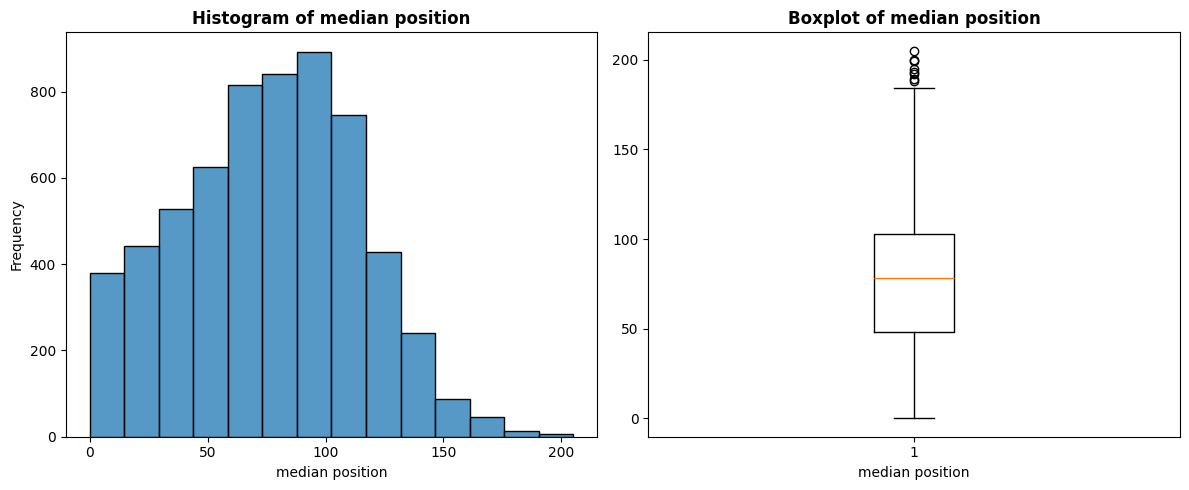

Outliers in median position: [np.int64(192), np.int64(193), np.int64(195), np.int64(199), np.int64(200), np.int64(205), np.int64(188), np.int64(189)]


,Name,Column,Lower Bound,Upper Bound,Outlier Value
5134,chris-barton,median position,0,185.5,205
5179,renan-ferraro,median position,0,185.5,188
5289,ramon-carretero,median position,0,185.5,192
5404,pedro-autran-dourado-dutra-nicacio,median position,0,185.5,193
5405,gabriel-machado-silva,median position,0,185.5,195
5477,sergio-jaramillo,median position,0,185.5,200
5674,rik-van-ijzendoorn,median position,0,185.5,189
5926,vadim-kravchenko,median position,0,185.5,199


Number of outliers in median position: 8


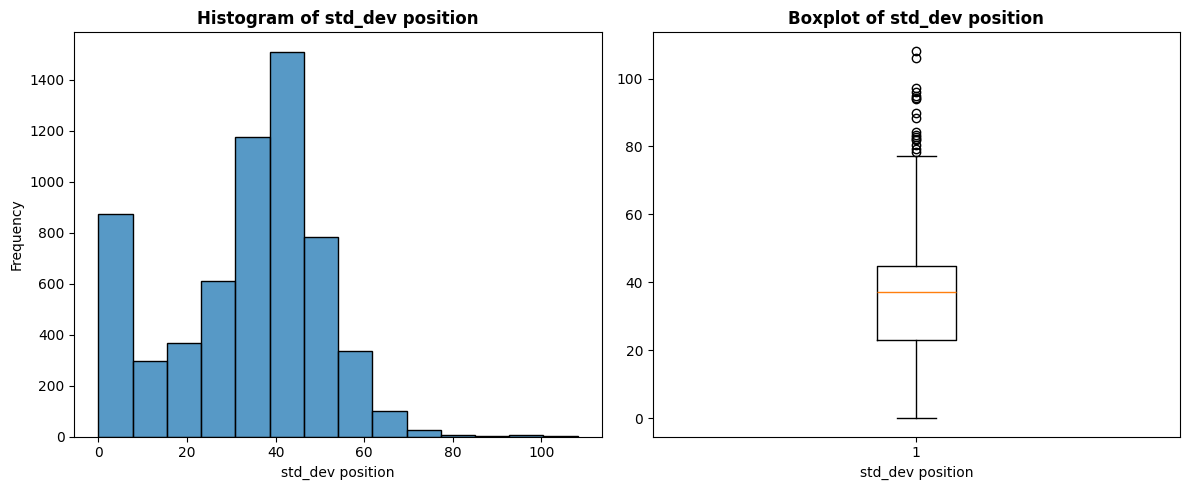

Outliers in std_dev position: [np.float64(96.16652224137046), np.float64(97.2745256135096), np.float64(106.06601717798212), np.float64(108.18733752154178), np.float64(78.48885271170677), np.float64(79.19595949289332), np.float64(80.49016503068351), np.float64(94.75230867899737), np.float64(81.94103571064582), np.float64(82.92365967161201), np.float64(84.11809879838313), np.float64(82.2455672564384), np.float64(83.43860018001261), np.float64(88.38834764831844), np.float64(89.77740329758454), np.float64(94.04520189781084), np.float64(94.40868604106298)]


,Name,Column,Lower Bound,Upper Bound,Outlier Value
2629,santiago-portillo-rosado,std_dev position,0.0,77.57,94.41
3820,lech-piasecki,std_dev position,0.0,77.57,84.12
3834,paul-watson,std_dev position,0.0,77.57,89.78
4432,nikolai-galitchanin,std_dev position,0.0,77.57,108.19
4905,sergei-sukhoruchenkov,std_dev position,0.0,77.57,97.27
5381,sylvain-bolay,std_dev position,0.0,77.57,94.75
5401,jose-inguanzo,std_dev position,0.0,77.57,106.07
5416,rustam-tukhvatulin,std_dev position,0.0,77.57,81.94
5430,michele-merlo,std_dev position,0.0,77.57,82.92
5475,pedro-jose-soler,std_dev position,0.0,77.57,79.20


Number of outliers in std_dev position: 17


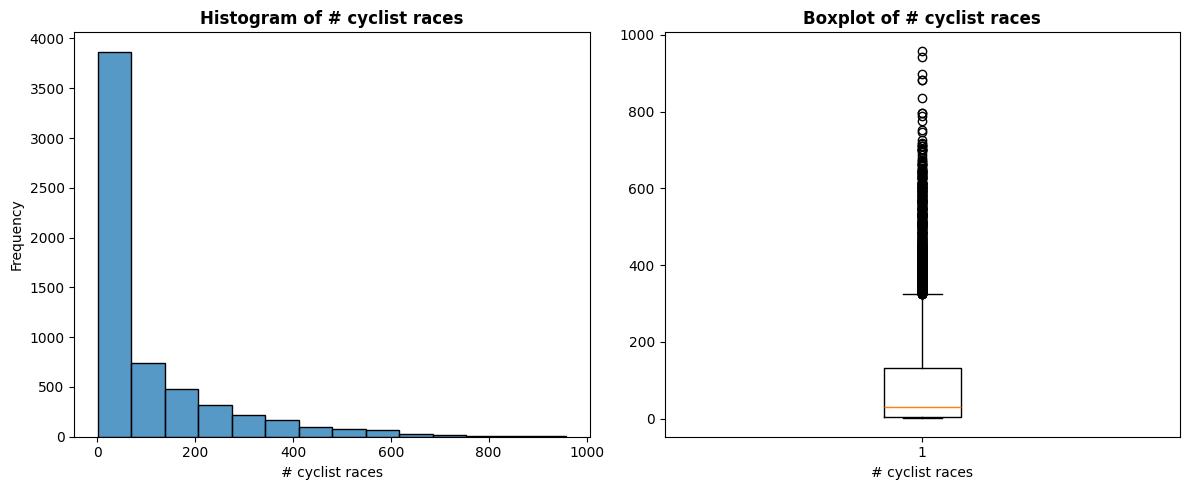

Outliers in # cyclist races: [np.int64(512), np.int64(513), np.int64(514), np.int64(515), np.int64(518), np.int64(519), np.int64(520), np.int64(522), np.int64(526), np.int64(527), np.int64(528), np.int64(529), np.int64(530), np.int64(531), np.int64(533), np.int64(534), np.int64(535), np.int64(537), np.int64(538), np.int64(544), np.int64(545), np.int64(546), np.int64(547), np.int64(549), np.int64(550), np.int64(552), np.int64(554), np.int64(556), np.int64(557), np.int64(559), np.int64(562), np.int64(563), np.int64(564), np.int64(565), np.int64(567), np.int64(568), np.int64(569), np.int64(570), np.int64(571), np.int64(574), np.int64(575), np.int64(576), np.int64(577), np.int64(581), np.int64(582), np.int64(583), np.int64(585), np.int64(587), np.int64(590), np.int64(591), np.int64(592), np.int64(594), np.int64(595), np.int64(597), np.int64(598), np.int64(600), np.int64(601), np.int64(603), np.int64(605), np.int64(606), np.int64(608), np.int64(609), np.int64(610), np.int64(612), np.int64(6

,Name,Column,Lower Bound,Upper Bound,Outlier Value
0,sean-kelly,# cyclist races,1,325.0,629
37,henk-lubberding,# cyclist races,1,325.0,346
56,joop-zoetemelk,# cyclist races,1,325.0,334
106,robert-gesink,# cyclist races,1,325.0,653
107,kenny-elissonde,# cyclist races,1,325.0,386
...,...,...,...,...,...
2701,marc-sergeant,# cyclist races,1,325.0,338
2708,steven-rooks,# cyclist races,1,325.0,332
2843,kim-kirchen,# cyclist races,1,325.0,329
2941,vladimir-gusev,# cyclist races,1,325.0,359


Number of outliers in # cyclist races: 530


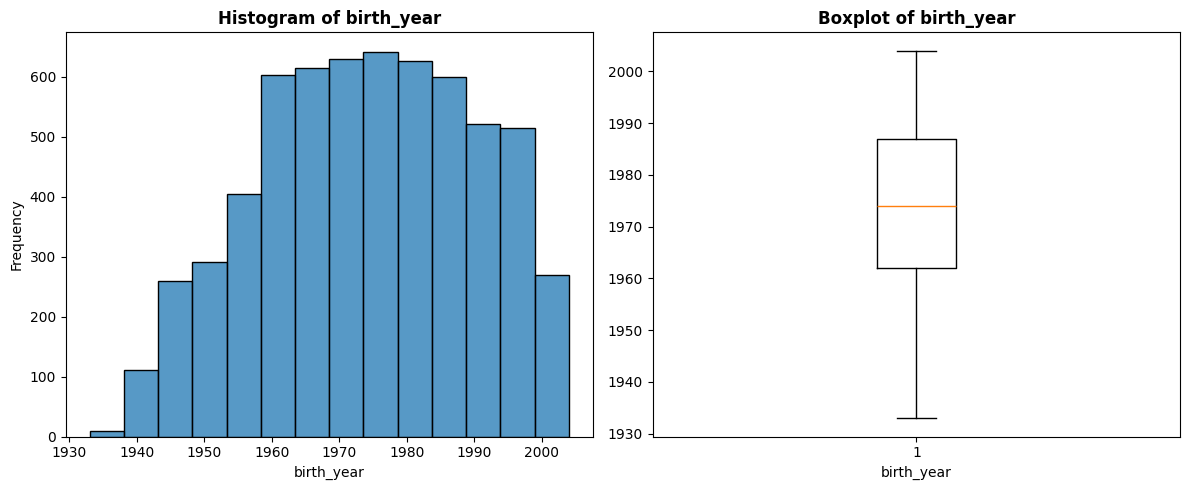

Outliers in birth_year: []
Number of outliers in birth_year: 0


In [487]:
for column in numeric_columns:
    show_hist_and_box_plot(cyclists,column)
    bounds = calculate_outlier_bounds(cyclists, column)
    lower_bound = round(bounds['lower'], 2)
    upper_bound = round(bounds['upper'], 2)
    
    outliers_list = []
    outliers = cyclists[
        (cyclists[column] < lower_bound) | (cyclists[column] > upper_bound)
    ]

    column_outliers_count = len(outliers)

    column_outliers_df = pd.DataFrame({
        "Name": outliers['name'],
        "Column": column,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Value": outliers[column].round(2)
    })
    if(column_outliers_count > 0):
        display(column_outliers_df)
    print(f"Number of outliers in {column}: {column_outliers_count}")

In [488]:
rows_with_outliers = check_all_outliers(numeric_cyclists_df, numeric_columns)

,BMI,median position,std_dev position,# cyclist races,birth_year,outlier_count,outlier_percentage
0,False,False,False,True,False,1,20.0
14,True,False,False,False,False,1,20.0
27,True,False,False,False,False,1,20.0
37,False,False,False,True,False,1,20.0
56,False,False,False,True,False,1,20.0
...,...,...,...,...,...,...,...
5926,False,True,False,False,False,1,20.0
5971,False,False,True,False,False,1,20.0
6001,True,False,False,False,False,1,20.0
6085,True,False,False,False,False,1,20.0


Total number of rows: 6095
Total rows with outliers: 618
Percentage of rows with outliers: 10.14%


In [489]:
rows_with_outliers[rows_with_outliers['outlier_count'] > 1]

,BMI,median position,std_dev position,# cyclist races,birth_year,outlier_count,outlier_percentage
241,True,False,False,True,False,2,40.0
565,True,False,False,True,False,2,40.0
1166,True,False,False,True,False,2,40.0


### Outliers elimination
For outlier elimination, we follow an approach that focuses on identifying the most extreme values by using intervals beyond the lower and upper bounds. This allows us to remove only the truly extreme outliers without significantly altering the distribution or the representativeness of the data. This way, we preserve the integrity of the dataset while addressing the issue of outliers effectively.


#### _# cyclist races_ (530)
We evaluate different ranges of values (in increments of 200) above the upper bound, selecting a reasonable threshold beyond which outliers are considered extreme

In [490]:
bound = calculate_outlier_bounds(cyclists, "# cyclist races")
lower_bound_n_cyclist_races = bound['lower']
upper_bound_n_cyclist_races = bound['upper']

In [491]:
analyze_outliers(cyclists, "# cyclist races", lower_bound_n_cyclist_races, upper_bound_n_cyclist_races, 7, 7, 100, 100)

Outliers above upper bound (325.0): 530
Outliers below lower bound (1): 0
Total outliers: 530
Number of outliers in the range of [325.0, 425.0]: 249
Number of outliers in the range of [425.0, 525.0]: 128
Number of outliers in the range of [525.0, 625.0]: 97
Number of outliers in the range of [625.0, 725.0]: 43
Number of outliers in the range of [725.0, 825.0]: 7
Number of outliers in the range of [825.0, 925.0]: 4
Number of outliers in the range of [925.0, 1025.0]: 2
Number of outliers > 1025.0: 0

No outliers below the lower bound.


We choose a value between [525, 625], which provides a good compromise for removing a significant number of outliers without overly altering the initial distribution. A value of 600 appears to be the most appropriate.

In [492]:
len(cyclists[cyclists['# cyclist races'] > 600])

73

For better statistical precision, we rely on a quartile value that is close to 600. It is about the 98nd percentile.

In [493]:
upper_extreme_quantile = cyclists["# cyclist races"].quantile(0.98)
upper_extreme_quantile

np.float64(549.1199999999999)

In [494]:
cleaned_cyclists_df = cyclists.copy()  

cleaned_cyclists_df = cleaned_cyclists_df[
    (cleaned_cyclists_df['# cyclist races'] <=  upper_extreme_quantile)
]

print(f"Remaining rows after removal: {len(cleaned_cyclists_df)}")
print(f"Removed rows: {len(cyclists) - len(cleaned_cyclists_df)}")

Remaining rows after removal: 5973
Removed rows: 122


As shown in the below distribution and box plot graphs for the _# cyclist races_ column, the cleaned data does not deviate significantly from the original values. The core structure and range of this column remain consistent, while the most extreme outliers (> 600) have been effectively removed. This ensures that the cleaning process focused specifically on this column without distorting its overall characteristics.

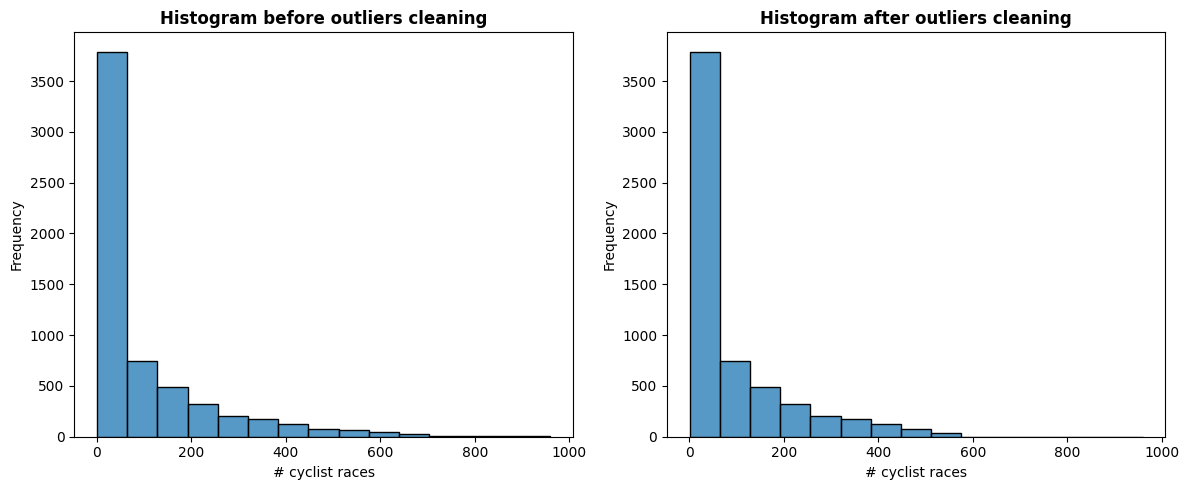

In [495]:
compare_distributions_consistent(cyclists, cleaned_cyclists_df, "# cyclist races")

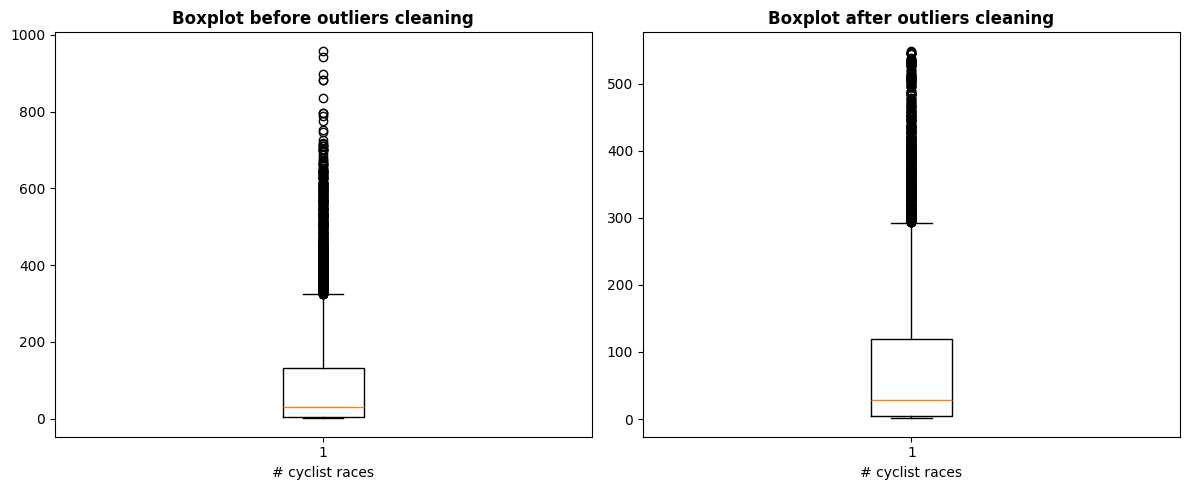

In [496]:
compare_box_plots(cyclists, cleaned_cyclists_df, "# cyclist races")

In [497]:
cleaned_cyclists_df
print(len(cyclists))
print(len(cleaned_cyclists_df))



6095
5973


#### BMI (66)


In [498]:
bound = calculate_outlier_bounds(cyclists, "BMI")
lower_bound_BMI = bound['lower']
upper_bound_BMI = bound['upper']


In [499]:
lower_bound_BMI

np.float64(17.639999999999997)

In [500]:
upper_bound_BMI

np.float64(24.76)

In [501]:
analyze_outliers(cyclists, "BMI", lower_bound_BMI, upper_bound_BMI, 4, 4, 0.5, 0.5)

Outliers above upper bound (24.76): 46
Outliers below lower bound (17.639999999999997): 20
Total outliers: 66
Number of outliers in the range of [24.76, 25.26]: 22
Number of outliers in the range of [25.26, 25.76]: 13
Number of outliers in the range of [25.76, 26.26]: 4
Number of outliers in the range of [26.26, 26.76]: 5
Number of outliers > 26.76: 2

Number of outliers in the range of [17.139999999999997, 17.639999999999997]: 14
Number of outliers in the range of [16.639999999999997, 17.139999999999997]: 3
Number of outliers in the range of [16.139999999999997, 16.639999999999997]: 3
Number of outliers in the range of [15.639999999999997, 16.139999999999997]: 0
Number of outliers < 15.639999999999997: 0


Let’s consider ‘extreme’ outliers as those below approximately 17.13 and above approximately 26.76. These thresholds correspond to the 0.092nd percentile  and the 99.98th percentile, respectively

In [502]:
lower_extreme_quantile = cyclists["BMI"].quantile(0.00092)
upper_extreme_quantile = cyclists["BMI"].quantile(0.9998)
print(lower_extreme_quantile)
print(upper_extreme_quantile)

17.14734698346165
26.77343600000001


In [503]:
len_before_cleaning = len(cleaned_cyclists_df)
cleaned_cyclists_df = cleaned_cyclists_df[
    (cleaned_cyclists_df['BMI'] <= upper_extreme_quantile) &
    (cleaned_cyclists_df['BMI'] >= lower_extreme_quantile)
]


print(f"Remaining rows after removal: {len(cleaned_cyclists_df)}")
print(f"Removed rows: {len_before_cleaning - len(cleaned_cyclists_df)}")


Remaining rows after removal: 5965
Removed rows: 8


As we can see, the distribution did not change much after removing the 8 most extreme outliers. Therefore, we expect this will not negatively impact the nature of the data.

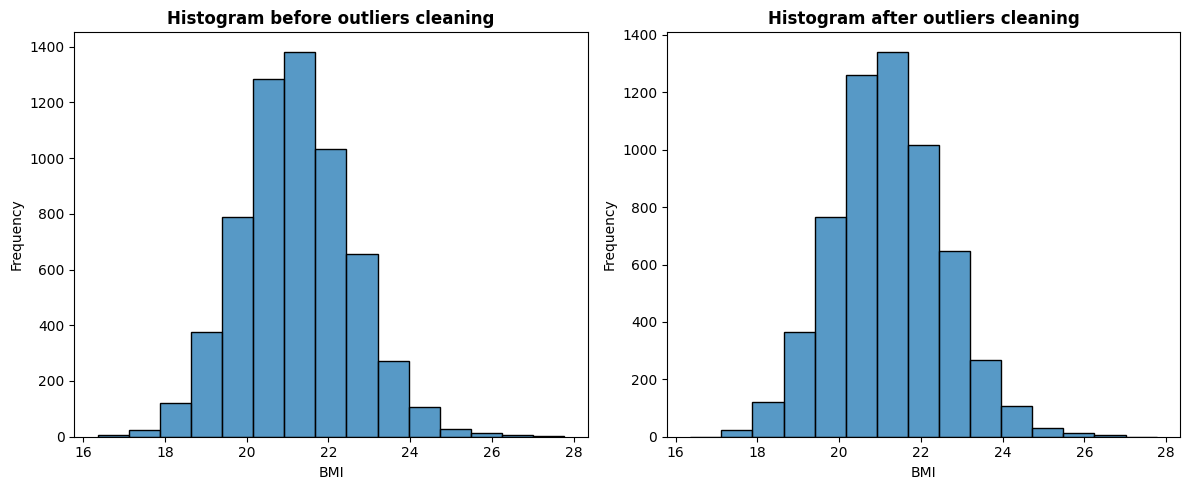

In [504]:
compare_distributions_consistent(cyclists, cleaned_cyclists_df, "BMI")

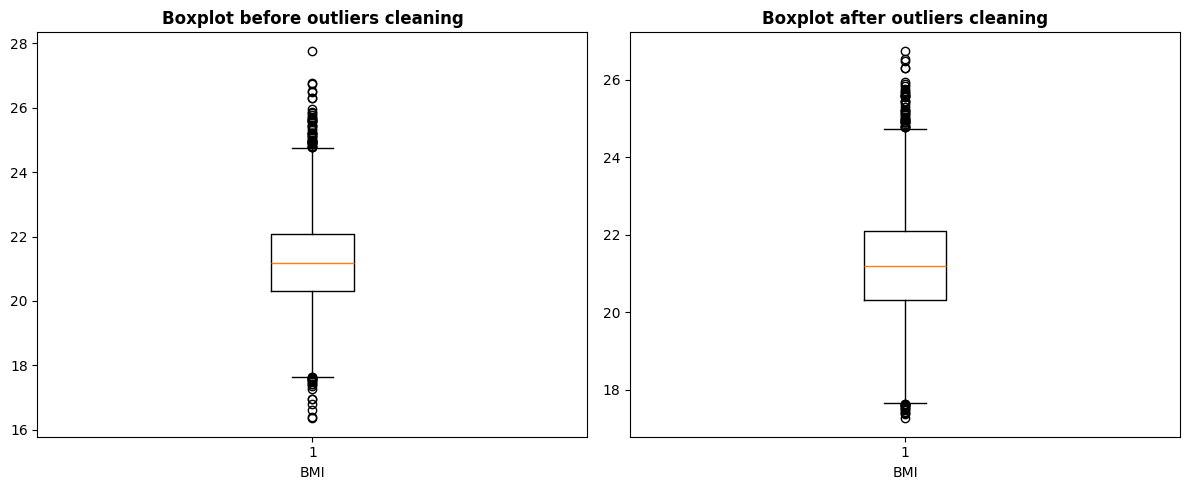

In [505]:
compare_box_plots(cyclists,cleaned_cyclists_df, "BMI")

#### std_dev position (17)

In [506]:
bound = calculate_outlier_bounds(cyclists, "std_dev position")
lower_bound_stdPos= bound['lower']
upper_bound_stdPos = bound['upper']


In [507]:
analyze_outliers(cyclists, "std_dev position", lower_bound_stdPos, upper_bound_stdPos, 6, 6, 5, 5)

Outliers above upper bound (77.56711891904379): 17
Outliers below lower bound (0.0): 0
Total outliers: 17
Number of outliers in the range of [77.56711891904379, 82.56711891904379]: 5
Number of outliers in the range of [82.56711891904379, 87.56711891904379]: 3
Number of outliers in the range of [87.56711891904379, 92.56711891904379]: 2
Number of outliers in the range of [92.56711891904379, 97.56711891904379]: 5
Number of outliers in the range of [97.56711891904379, 102.56711891904379]: 0
Number of outliers in the range of [102.56711891904379, 107.56711891904379]: 1
Number of outliers > 107.56711891904379: 1

No outliers below the lower bound.


Let’s consider ‘extreme’ outliers as those above approximately 97.56, so the two most extreme ones. These thresholds correspond to the 99.97nd percentile.

In [508]:
upper_extreme_quantile = cyclists["std_dev position"].quantile(0.9997)
upper_extreme_quantile

np.float64(98.78490386428663)

In [509]:
len_before_cleaning = len(cleaned_cyclists_df)
cleaned_cyclists_df = cleaned_cyclists_df[(cleaned_cyclists_df['std_dev position'] <= upper_extreme_quantile)]

print(f"Remaining rows after removal: {len(cleaned_cyclists_df)}")
print(f"Removed rows: {len_before_cleaning - len(cleaned_cyclists_df)}")

Remaining rows after removal: 5963
Removed rows: 2


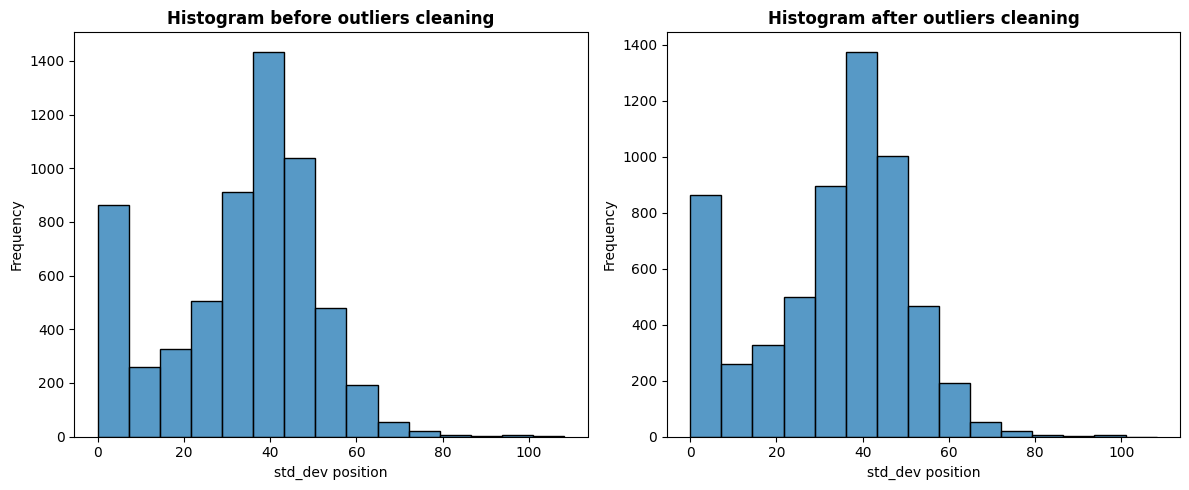

In [510]:
compare_distributions_consistent(cyclists, cleaned_cyclists_df, "std_dev position")

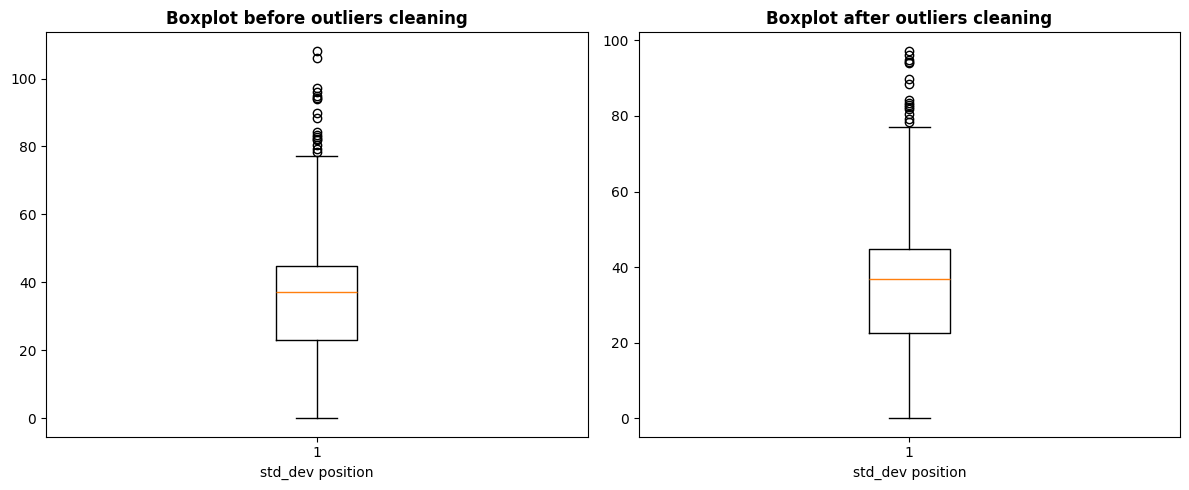

In [511]:
compare_box_plots(cyclists, cleaned_cyclists_df, "std_dev position",)

#### median position (8)

In [512]:
bound = calculate_outlier_bounds(cyclists, "median position")
lower_bound_medianPos = bound['lower']
upper_bound_medianPos = bound['upper']

In [513]:
print(lower_bound_medianPos)
print(upper_bound_medianPos)

0
185.5


In [514]:
analyze_outliers(cyclists, "median position", lower_bound_medianPos, upper_bound_medianPos, 6, 6, 5, 5)

Outliers above upper bound (185.5): 8
Outliers below lower bound (0): 0
Total outliers: 8
Number of outliers in the range of [185.5, 190.5]: 2
Number of outliers in the range of [190.5, 195.5]: 3
Number of outliers in the range of [195.5, 200.5]: 2
Number of outliers in the range of [200.5, 205.5]: 1
Number of outliers in the range of [205.5, 210.5]: 0
Number of outliers in the range of [210.5, 215.5]: 0
Number of outliers > 215.5: 0

No outliers below the lower bound.


Since there are no outliers that can be considered much more extreme than others, we try to eliminate all outliers and test the resulting distribution.

In [515]:
len_before_cleaning = len(cleaned_cyclists_df)
cleaned_cyclists_df = cleaned_cyclists_df[
        (cleaned_cyclists_df["median position"] >= lower_bound_medianPos) & (cleaned_cyclists_df["median position"] <= upper_bound_medianPos)
    ]

print(f"Remaining rows after removal: {len(cleaned_cyclists_df)}")
print(f"Removed rows: {len_before_cleaning - len(cleaned_cyclists_df)}")

Remaining rows after removal: 5955
Removed rows: 8


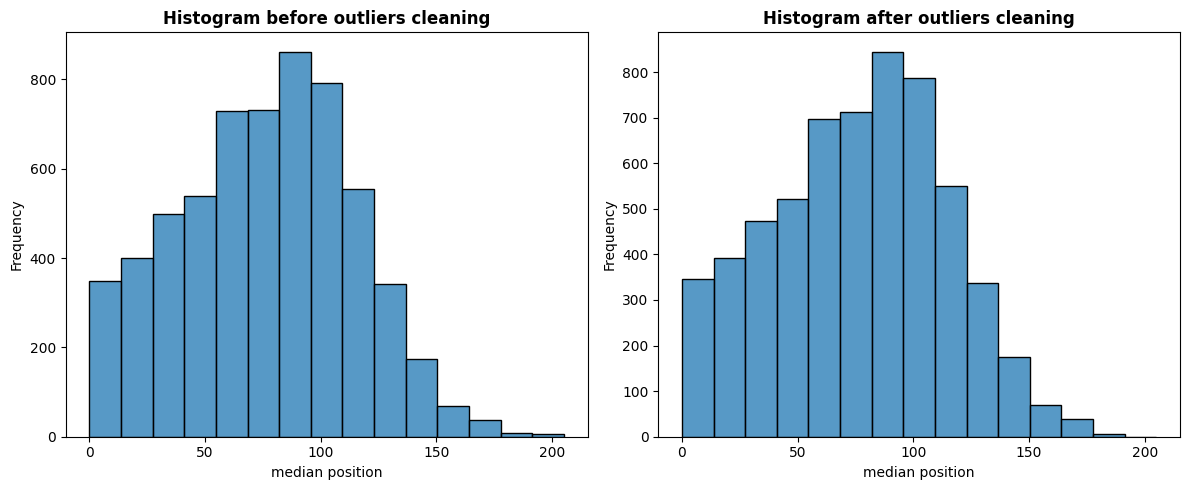

In [516]:
compare_distributions_consistent(cyclists, cleaned_cyclists_df, "median position")

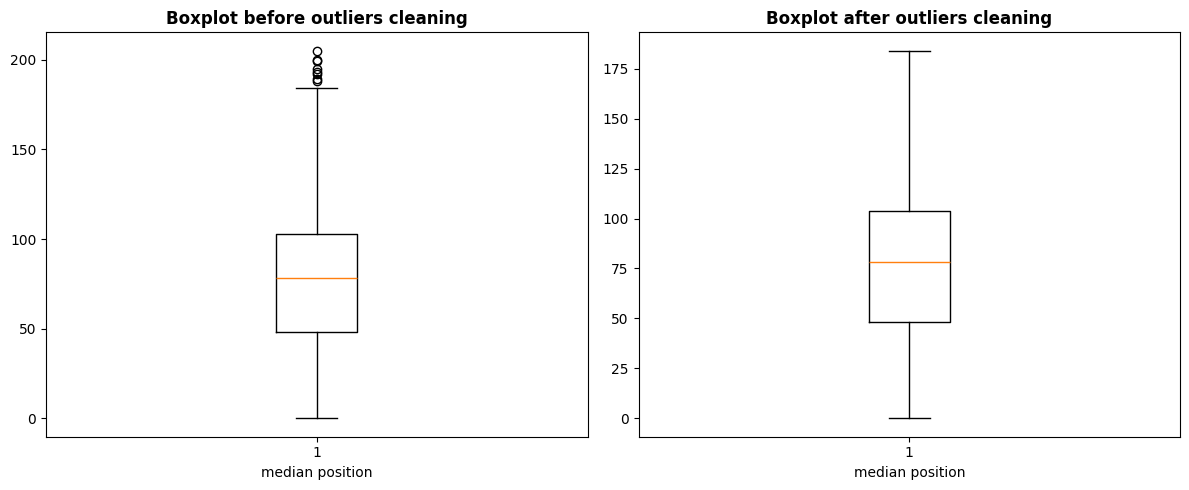

In [517]:
compare_box_plots(cyclists, cleaned_cyclists_df, "median position")

As can be seen from the box plots and distributions above, removing all outliers has not significantly altered the nature of the data.

In [518]:
print(f"Number of rows of cyclists dataframe before applying outliers elimination: {cyclists.shape[0]}")

Number of rows of cyclists dataframe before applying outliers elimination: 6095


In [519]:
print(f"Number of rows of cyclists dataframe after applying outliers elimination: {cleaned_cyclists_df.shape[0]}")

Number of rows of cyclists dataframe after applying outliers elimination: 5955


In [520]:
# cleaned_cyclists_df.to_csv("../../dataset/preprocessedCyclists_without_outliers.csv", index=False)

# Outliers Detection for races

In [521]:
numeric_races_df = races[['points', 'climb/length', 'median_delta', 'std_delta', 'startlist_quality', 'climb_total', 'length']]
numeric_races_df

,points,climb/length,median_delta,std_delta,startlist_quality,climb_total,length
0,100,0.006796,27.0,6.847590,1241,1101,162000
1,80,0.028444,1957.0,873.835670,821,5575,196000
2,100,0.006102,29.0,44.079531,1699,781,128000
3,50,0.008395,53.0,27.154498,804,68,8100
4,100,0.019404,1376.0,675.354230,1551,3743,192900
...,...,...,...,...,...,...,...
5276,80,0.009736,77.0,120.702086,881,1441,148000
5277,275,0.009700,270.0,327.665558,808,2648,273000
5278,50,0.009330,0.0,0.000000,779,1726,185000
5279,50,0.013783,209.0,176.293335,1045,1880,136400


In [522]:
numeric_races_df.isna().sum()

points               0
climb/length         0
median_delta         0
std_delta            0
startlist_quality    0
climb_total          0
length               0
dtype: int64

Check pearson correlation between these non-nan numeric features

,points,climb/length,median_delta,std_delta,startlist_quality,climb_total,length
points,1.000000,-0.064540,0.035331,0.051223,0.150270,0.222756,0.443516
climb/length,-0.064540,1.000000,0.191377,0.223502,0.015309,0.430213,-0.171295
median_delta,0.035331,0.191377,1.000000,0.793629,0.096597,0.303302,0.075307
std_delta,0.051223,0.223502,0.793629,1.000000,0.069962,0.301224,0.117848
startlist_quality,0.150270,0.015309,0.096597,0.069962,1.000000,0.095901,0.075864
climb_total,0.222756,0.430213,0.303302,0.301224,0.095901,1.000000,0.590508
length,0.443516,-0.171295,0.075307,0.117848,0.075864,0.590508,1.000000


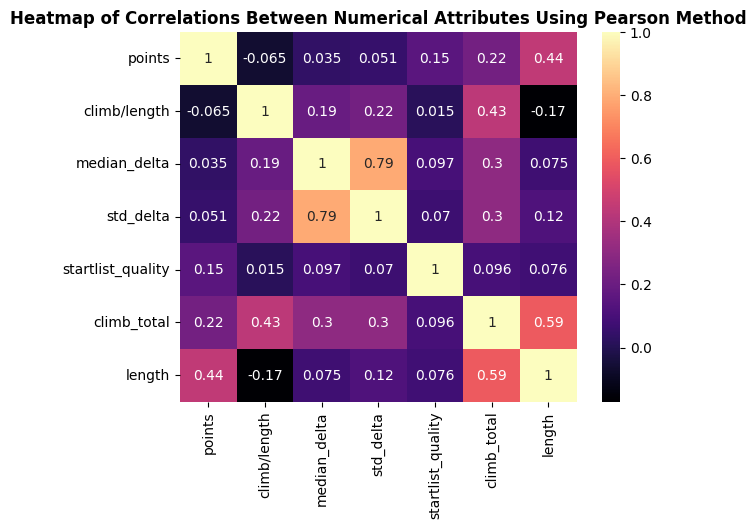

In [523]:
pearson_matrix = numeric_races_df.corr(method='pearson')
display(pearson_matrix)
sbn.heatmap(pearson_matrix, annot=True, cmap="magma")
plt.title("Heatmap of Correlations Between Numerical Attributes Using Pearson Method", fontweight='bold')
plt.show()
plt.close()

Since _std\_delta_ and _median\_delta_ are highly correlated, we decide to drop _std\_delta_. Also _climb\_total_ and _length_ are moderately correlated.
Given that we already have the feature _climb/total_, we chose to drop _climb\_total_  while retaining _length_

In [524]:
numeric_races_df = numeric_races_df.drop(['std_delta', 'climb_total'], axis=1)
numeric_races_df

,points,climb/length,median_delta,startlist_quality,length
0,100,0.006796,27.0,1241,162000
1,80,0.028444,1957.0,821,196000
2,100,0.006102,29.0,1699,128000
3,50,0.008395,53.0,804,8100
4,100,0.019404,1376.0,1551,192900
...,...,...,...,...,...
5276,80,0.009736,77.0,881,148000
5277,275,0.009700,270.0,808,273000
5278,50,0.009330,0.0,779,185000
5279,50,0.013783,209.0,1045,136400


In [525]:
numeric_columns = numeric_races_df.columns
numeric_races_df['_url'] = races['_url']
numeric_races_df

,points,climb/length,median_delta,startlist_quality,length,_url
0,100,0.006796,27.0,1241,162000,tour-de-france/1978/stage-6
1,80,0.028444,1957.0,821,196000,vuelta-a-espana/2016/stage-14
2,100,0.006102,29.0,1699,128000,tour-de-france/2019/stage-21
3,50,0.008395,53.0,804,8100,volta-a-catalunya/1999/prologue
4,100,0.019404,1376.0,1551,192900,tour-de-france/2022/stage-9
...,...,...,...,...,...,...
5276,80,0.009736,77.0,881,148000,giro-d-italia/2017/stage-3
5277,275,0.009700,270.0,808,273000,paris-roubaix/2000/result
5278,50,0.009330,0.0,779,185000,paris-nice/1976/stage-2
5279,50,0.013783,209.0,1045,136400,volta-a-catalunya/2016/stage-7


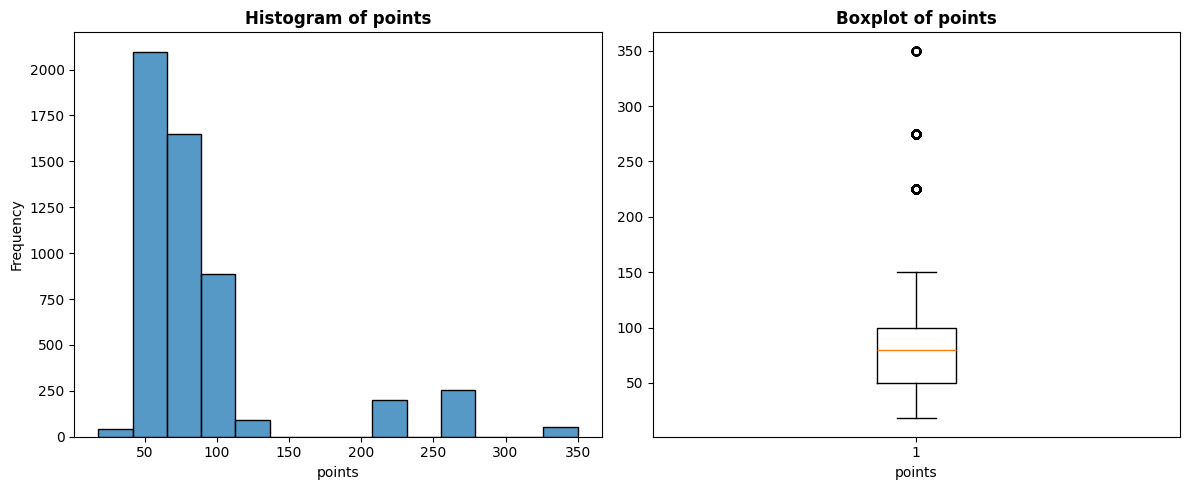

Outliers in points: [np.int64(225), np.int64(275), np.int64(350)]


,Url,Column,Lower Bound,Upper Bound,Outlier Value
13,ronde-van-vlaanderen/1980/result,points,18,175.0,275
15,milano-sanremo/2004/result,points,18,175.0,275
48,la-fleche-wallone/2015/result,points,18,175.0,225
69,liege-bastogne-liege/1999/result,points,18,175.0,275
74,paris-roubaix/2021/result,points,18,175.0,275
...,...,...,...,...,...
5244,milano-sanremo/1996/result,points,18,175.0,275
5248,amstel-gold-race/2013/result,points,18,175.0,225
5268,san-sebastian/2017/result,points,18,175.0,225
5269,gp-quebec/2010/result,points,18,175.0,225


Number of outliers in points: 510


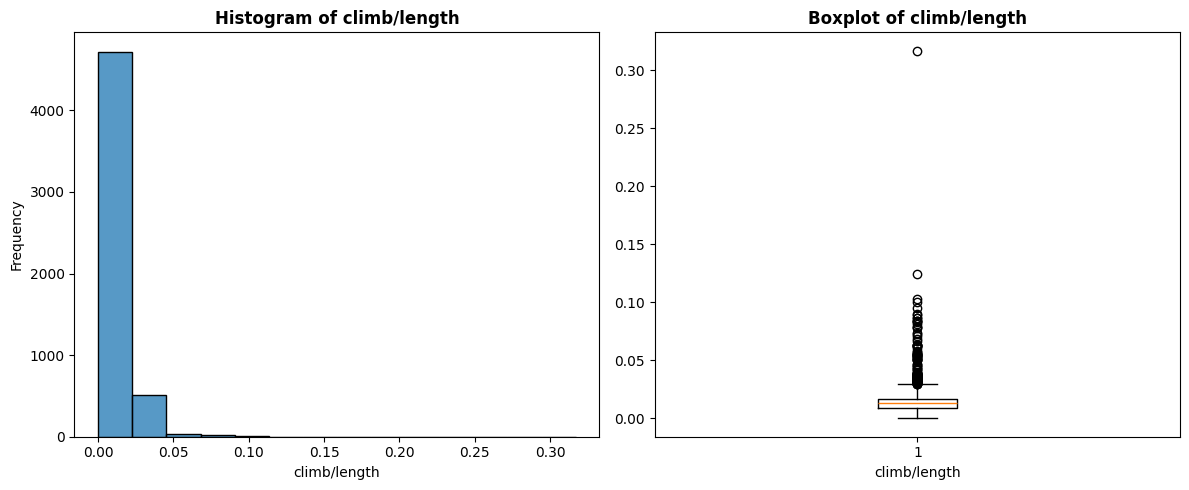

Outliers in climb/length: [np.float64(0.0355151515151515), np.float64(0.0625), np.float64(0.1032608695652173), np.float64(0.0509278350515463), np.float64(0.0380655737704918), np.float64(0.0314965517241379), np.float64(0.08975), np.float64(0.0300884955752212), np.float64(0.0321134751773049), np.float64(0.0417777777777777), np.float64(0.0365653710247349), np.float64(0.0527184466019417), np.float64(0.0712666666666666), np.float64(0.0316091954022988), np.float64(0.05821875), np.float64(0.08375), np.float64(0.0788888888888888), np.float64(0.0510163934426229), np.float64(0.0374453781512605), np.float64(0.0314410774410774), np.float64(0.0343589743589743), np.float64(0.0383529411764705), np.float64(0.0502364864864864), np.float64(0.0423391812865497), np.float64(0.0332473684210526), np.float64(0.0303030303030303), np.float64(0.0305527065527065), np.float64(0.0301204819277108), np.float64(0.095), np.float64(0.0426), np.float64(0.0726851851851851), np.float64(0.0357843137254901), np.float64(0.087

,Url,Column,Lower Bound,Upper Bound,Outlier Value
5,vuelta-a-espana/2017/stage-20,climb/length,0.0,0.03,0.032
18,giro-d-italia/2019/stage-14,climb/length,0.0,0.03,0.032
35,giro-d-italia/2004/stage-18,climb/length,0.0,0.03,0.032
37,vuelta-a-espana/2019/stage-9,climb/length,0.0,0.03,0.035
86,vuelta-a-espana/1993/stage-6,climb/length,0.0,0.03,0.034
...,...,...,...,...,...
5088,tour-de-france/1979/stage-2,climb/length,0.0,0.03,0.061
5161,tour-de-suisse/1976/prologue,climb/length,0.0,0.03,0.090
5169,vuelta-a-espana/1992/stage-9,climb/length,0.0,0.03,0.032
5175,tour-de-france/2021/stage-9,climb/length,0.0,0.03,0.032


Number of outliers in climb/length: 145


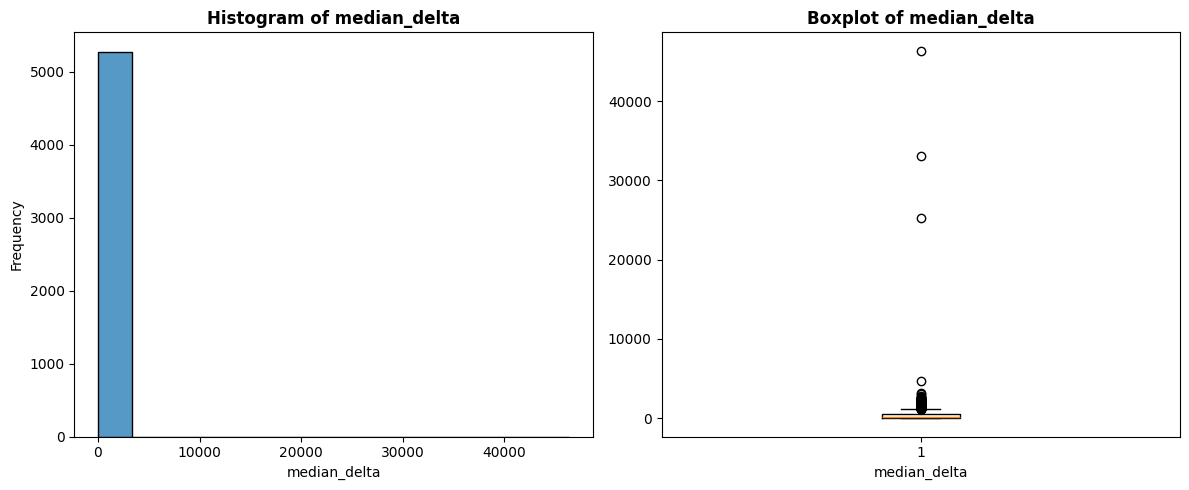

Outliers in median_delta: [np.float64(2048.0), np.float64(2060.0), np.float64(2062.0), np.float64(2072.0), np.float64(2080.0), np.float64(2083.0), np.float64(2090.0), np.float64(2101.0), np.float64(2109.5), np.float64(2120.0), np.float64(2126.0), np.float64(2140.0), np.float64(2154.0), np.float64(2156.0), np.float64(2169.0), np.float64(2185.0), np.float64(2191.0), np.float64(2193.0), np.float64(2199.0), np.float64(2208.0), np.float64(2210.0), np.float64(2216.0), np.float64(2244.0), np.float64(2274.5), np.float64(2365.0), np.float64(2368.5), np.float64(2370.0), np.float64(2373.0), np.float64(2399.0), np.float64(2419.0), np.float64(33140.0), np.float64(2426.0), np.float64(2500.0), np.float64(2562.0), np.float64(2657.0), np.float64(25223.0), np.float64(4751.0), np.float64(2732.0), np.float64(2825.0), np.float64(3018.0), np.float64(3234.0), np.float64(1187.0), np.float64(1189.0), np.float64(1193.0), np.float64(1194.0), np.float64(1195.0), np.float64(1199.0), np.float64(1200.0), np.float64(

,Url,Column,Lower Bound,Upper Bound,Outlier Value
1,vuelta-a-espana/2016/stage-14,median_delta,0.0,1186.25,1957.0
4,tour-de-france/2022/stage-9,median_delta,0.0,1186.25,1376.0
14,volta-a-catalunya/2015/stage-4,median_delta,0.0,1186.25,1669.0
18,giro-d-italia/2019/stage-14,median_delta,0.0,1186.25,1529.0
35,giro-d-italia/2004/stage-18,median_delta,0.0,1186.25,1423.0
...,...,...,...,...,...
5233,giro-d-italia/2015/stage-19,median_delta,0.0,1186.25,2562.0
5255,giro-d-italia/2021/stage-6,median_delta,0.0,1186.25,1287.5
5262,tour-de-romandie/2002/stage-2,median_delta,0.0,1186.25,1860.0
5266,dauphine/2015/stage-6,median_delta,0.0,1186.25,2185.0


Number of outliers in median_delta: 402


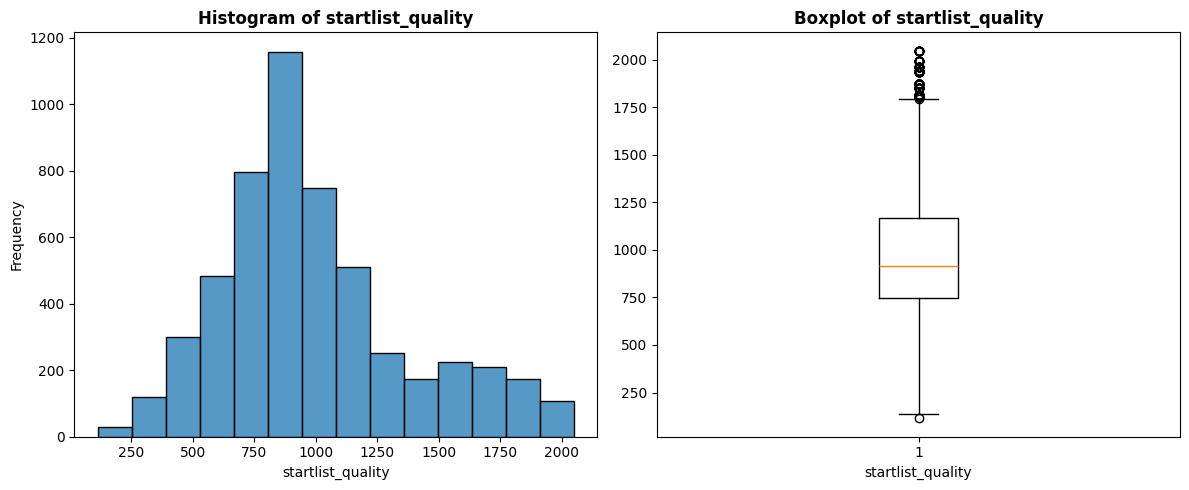

Outliers in startlist_quality: [np.int64(1794), np.int64(1959), np.int64(1994), np.int64(1804), np.int64(1933), np.int64(1871), np.int64(1872), np.int64(115), np.int64(1812), np.int64(1941), np.int64(1849), np.int64(2047)]


,Url,Column,Lower Bound,Upper Bound,Outlier Value
39,tour-de-france/1997/stage-15,startlist_quality,120.0,1792.0,1994
72,tour-de-france/1997/stage-2,startlist_quality,120.0,1792.0,1994
90,tour-de-france/1990/stage-1,startlist_quality,120.0,1792.0,1959
94,tour-de-france/1992/stage-7,startlist_quality,120.0,1792.0,2047
164,tour-de-france/1990/stage-9,startlist_quality,120.0,1792.0,1959
...,...,...,...,...,...
5125,tour-de-france/1987/stage-3,startlist_quality,120.0,1792.0,1812
5153,world-championship/1991/result,startlist_quality,120.0,1792.0,1794
5180,tour-de-france/1991/stage-19,startlist_quality,120.0,1792.0,1933
5190,tour-de-france/1997/stage-7,startlist_quality,120.0,1792.0,1994


Number of outliers in startlist_quality: 260


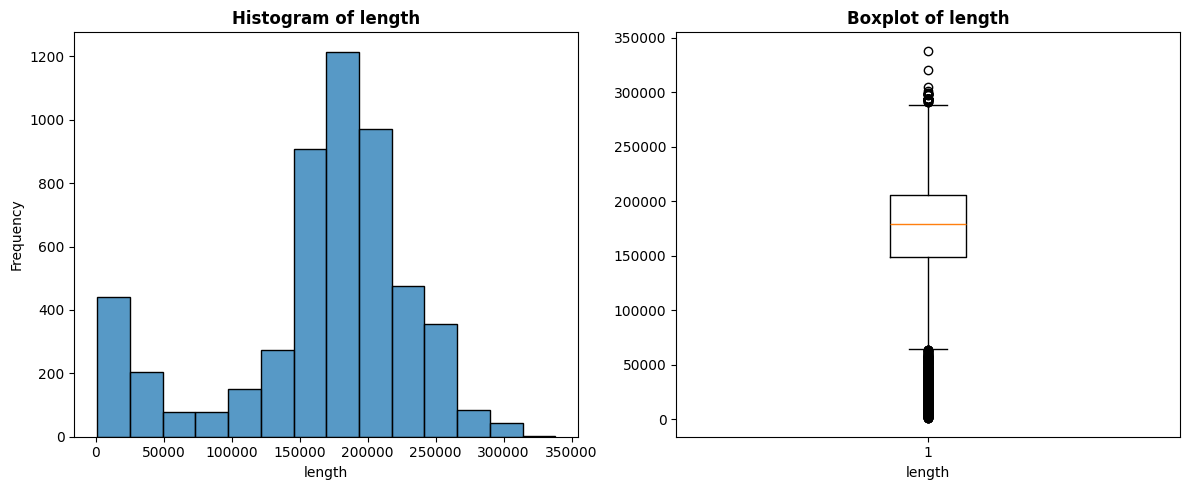

Outliers in length: [np.int64(4100), np.int64(59400), np.int64(8200), np.int64(12300), np.int64(63500), np.int64(16400), np.int64(20500), np.int64(24600), np.int64(36900), np.int64(41000), np.int64(297000), np.int64(53300), np.int64(6200), np.int64(61500), np.int64(14400), np.int64(18500), np.int64(26700), np.int64(30800), np.int64(338000), np.int64(34900), np.int64(39000), np.int64(4200), np.int64(6250), np.int64(59500), np.int64(12400), np.int64(16500), np.int64(20600), np.int64(24700), np.int64(37000), np.int64(293000), np.int64(6300), np.int64(57500), np.int64(10400), np.int64(14500), np.int64(18600), np.int64(26800), np.int64(30900), np.int64(35000), np.int64(291000), np.int64(55500), np.int64(4300), np.int64(8400), np.int64(12500), np.int64(33000), np.int64(37100), np.int64(41200), np.int64(53500), np.int64(6400), np.int64(22800), np.int64(26900), np.int64(31000), np.int64(8500), np.int64(12600), np.int64(18750), np.int64(49500), np.int64(6500), np.int64(18800), np.int64(27000), 

,Url,Column,Lower Bound,Upper Bound,Outlier Value
3,volta-a-catalunya/1999/prologue,length,64250.0,290250.0,8100
6,tour-de-france/1978/stage-14,length,64250.0,290250.0,52000
8,volta-a-catalunya/1981/stage-2b,length,64250.0,290250.0,30000
9,paris-nice/1994/stage-8b,length,64250.0,290250.0,12500
15,milano-sanremo/2004/result,length,64250.0,290250.0,294000
...,...,...,...,...,...
5241,milano-sanremo/2019/result,length,64250.0,290250.0,291000
5243,tour-de-france/1990/stage-5,length,64250.0,290250.0,301000
5244,milano-sanremo/1996/result,length,64250.0,290250.0,294000
5260,vuelta-a-espana/1997/stage-21,length,64250.0,290250.0,43000


Number of outliers in length: 749


In [526]:
for column in numeric_columns:
    show_hist_and_box_plot(races,column)
    bounds = calculate_outlier_bounds(races, column)
    lower_bound = round(bounds['lower'], 3)
    upper_bound = round(bounds['upper'], 3)
    
    outliers_list = []
    outliers = races[
        (races[column] < lower_bound) | (races[column] > upper_bound)
    ]

    column_outliers_count = len(outliers)

    column_outliers_df = pd.DataFrame({
        "Url": outliers['_url'],
        "Column": column,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Value": outliers[column].round(3)
    })
    if(column_outliers_count > 0):
        display(column_outliers_df)
    print(f"Number of outliers in {column}: {column_outliers_count}")

In [527]:
rows_with_outliers = check_all_outliers(numeric_races_df, numeric_columns)

,points,climb/length,median_delta,startlist_quality,length,outlier_count,outlier_percentage
1,False,False,True,False,False,1,20.0
3,False,False,False,False,True,1,20.0
4,False,False,True,False,False,1,20.0
5,False,True,False,False,False,1,20.0
6,False,False,False,False,True,1,20.0
...,...,...,...,...,...,...,...
5268,True,False,False,False,False,1,20.0
5269,True,False,False,False,False,1,20.0
5275,False,False,True,False,False,1,20.0
5277,True,False,False,False,False,1,20.0


Total number of rows: 5281
Total rows with outliers: 1823
Percentage of rows with outliers: 34.52%


In [528]:
rows_with_outliers['outlier_count'].value_counts()

outlier_count
1    1593
2     215
3      15
Name: count, dtype: int64

In [529]:
rows_with_outliers[rows_with_outliers['outlier_count'] == 2]

,points,climb/length,median_delta,startlist_quality,length,outlier_count,outlier_percentage
15,True,False,False,False,True,2,40.0
18,False,True,True,False,False,2,40.0
35,False,True,True,False,False,2,40.0
37,False,True,True,False,False,2,40.0
39,False,False,True,True,False,2,40.0
...,...,...,...,...,...,...,...
5175,False,True,True,False,False,2,40.0
5197,False,True,False,False,True,2,40.0
5241,True,False,False,False,True,2,40.0
5243,False,False,False,True,True,2,40.0


In [530]:
rows_with_outliers[rows_with_outliers['outlier_count'] == 3]

,points,climb/length,median_delta,startlist_quality,length,outlier_count,outlier_percentage
188,False,True,True,True,False,3,60.0
536,False,True,True,True,False,3,60.0
832,False,True,False,True,True,3,60.0
918,False,True,True,True,False,3,60.0
1144,False,True,False,True,True,3,60.0
1156,False,True,False,True,True,3,60.0
1534,False,True,True,True,False,3,60.0
2784,False,True,False,True,True,3,60.0
3762,False,True,True,True,False,3,60.0
3766,False,True,True,True,False,3,60.0


### Outliers elimination

#### points (510)

In [531]:
races['points'].value_counts().sort_index()

points
18        2
20        7
30       30
35        1
50     2098
70       21
75       32
80     1597
100     889
125      93
150       1
225     201
275     256
350      53
Name: count, dtype: int64

In [532]:
bound = calculate_outlier_bounds(races, "points")
lower_bound_points = bound['lower']
upper_bound_points = bound['upper']

In [533]:
print(lower_bound_points)
print(upper_bound_points)

18
175.0


In [534]:
analyze_outliers(races, "points", lower_bound_points, upper_bound_points, 7, 7, 20, 20)

Outliers above upper bound (175.0): 510
Outliers below lower bound (18): 0
Total outliers: 510
Number of outliers in the range of [175.0, 195.0]: 0
Number of outliers in the range of [195.0, 215.0]: 0
Number of outliers in the range of [215.0, 235.0]: 201
Number of outliers in the range of [235.0, 255.0]: 0
Number of outliers in the range of [255.0, 275.0]: 0
Number of outliers in the range of [275.0, 295.0]: 256
Number of outliers in the range of [295.0, 315.0]: 0
Number of outliers > 315.0: 53

No outliers below the lower bound.


The most extreme outliers appear to be those with values > 315, which are all points = 350.

In [535]:
races[races['points'] > 315]['points'].value_counts()

points
350    53
Name: count, dtype: int64

Points column represents fixed scores assigned to various types of cycling races. These scores are predetermined, and the values range from 18 to 350. According to the outliers detection, values above **175** are considered outliers. However, this results in identifying **510** rows as outliers, which is a substantial portion of the dataset. Removing all these rows would drastically alter the distribution. To address this issue, we analyzed different portions above 175 to identify the most extreme outliers.

Through this process, we observed that the most extreme outliers were those with the value 350, and all 53 of them are identical. These rows represent fixed scores that are meaningful in the context of the dataset. 
Since these high scores are predetermined and correspond to a specific category of races, it makes more sense to retain them in the dataset. This ensures that the clusters or future analyses are not biased by the absence of certain race types.

#### climb/length (145)

In [536]:
bound = calculate_outlier_bounds(races, "climb/length")
lower_bound_climb_length = bound['lower']
upper_bound_climb_length = bound['upper']

In [537]:
print(lower_bound_climb_length)
print(upper_bound_climb_length)

6.864988558352403e-05
0.029871531553300402


In [538]:
analyze_outliers(races, "climb/length", lower_bound_climb_length, upper_bound_climb_length, 8, 8, 0.01, 0.01)

Outliers above upper bound (0.029871531553300402): 147
Outliers below lower bound (6.864988558352403e-05): 0
Total outliers: 147
Number of outliers in the range of [0.029871531553300402, 0.0398715315533004]: 65
Number of outliers in the range of [0.0398715315533004, 0.0498715315533004]: 31
Number of outliers in the range of [0.0498715315533004, 0.0598715315533004]: 15
Number of outliers in the range of [0.0598715315533004, 0.0698715315533004]: 14
Number of outliers in the range of [0.0698715315533004, 0.0798715315533004]: 5
Number of outliers in the range of [0.0798715315533004, 0.0898715315533004]: 8
Number of outliers in the range of [0.0898715315533004, 0.0998715315533004]: 4
Number of outliers in the range of [0.0998715315533004, 0.1098715315533004]: 3
Number of outliers > 0.1098715315533004: 2

No outliers below the lower bound.


Given the ranges above, it might be quite "safe" to try to consider outliers beyond 0.069 as extreme. It is about the 99.6th percentile.

In [539]:
upper_extreme_quantile = races["climb/length"].quantile(0.996)
upper_extreme_quantile

np.float64(0.06634685185185217)

In [540]:
cleaned_races_df = races.copy()  

cleaned_races_df = cleaned_races_df[
    (cleaned_races_df['climb/length'] <=  upper_extreme_quantile)
]

print(f"Remaining rows after removal: {len(cleaned_races_df)}")
print(f"Removed rows: {len(races) - len(cleaned_races_df)}")

Remaining rows after removal: 5259
Removed rows: 22


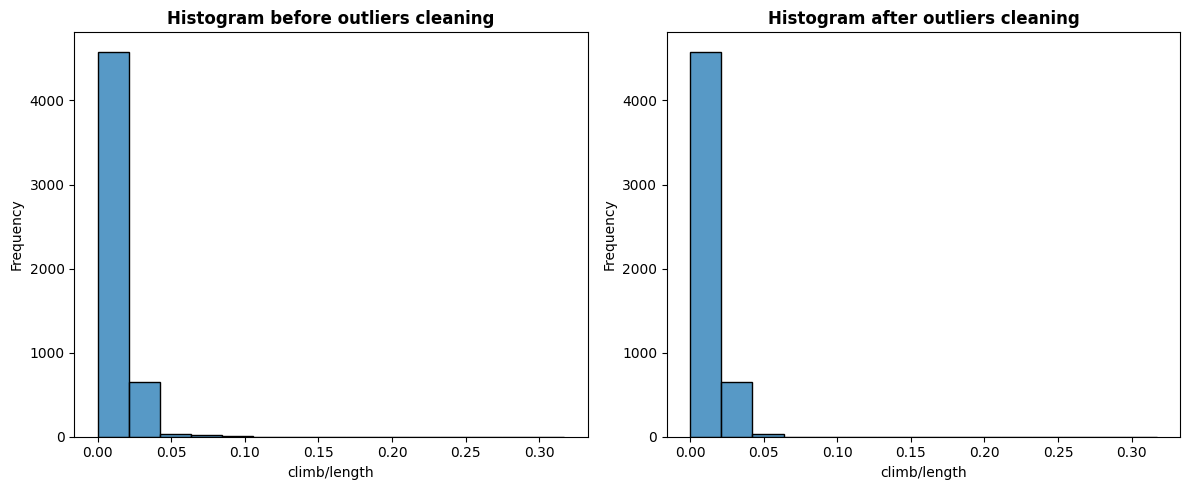

In [541]:
compare_distributions_consistent(races, cleaned_races_df, "climb/length")

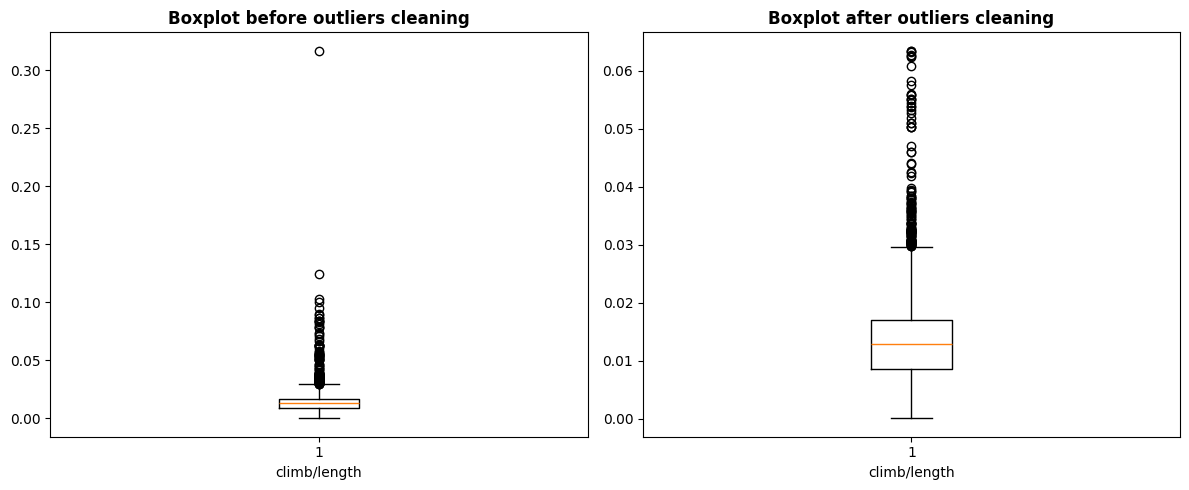

In [542]:
compare_box_plots(races, cleaned_races_df, "climb/length")

As we can see, the distribution has not been significantly altered. The box plot now provides a better and more understandable visualization.

#### median_delta (402)

In [543]:
bound = calculate_outlier_bounds(races, "median_delta")
lower_bound_median_delta= bound['lower']
upper_bound_median_delta = bound['upper']

In [544]:
print(lower_bound_median_delta)
print(upper_bound_median_delta)

0.0
1186.25


In [545]:
analyze_outliers(races, "median_delta", lower_bound_median_delta, upper_bound_median_delta, 6, 6, 1000, 1000)

Outliers above upper bound (1186.25): 402
Outliers below lower bound (0.0): 0
Total outliers: 402
Number of outliers in the range of [1186.25, 2186.25]: 375
Number of outliers in the range of [2186.25, 3186.25]: 22
Number of outliers in the range of [3186.25, 4186.25]: 1
Number of outliers in the range of [4186.25, 5186.25]: 1
Number of outliers in the range of [5186.25, 6186.25]: 0
Number of outliers in the range of [6186.25, 7186.25]: 0
Number of outliers > 7186.25: 3

No outliers below the lower bound.


In [546]:
races['median_delta'].value_counts().sort_index()

median_delta
0.0        1195
0.5           1
1.0          19
2.0          39
2.5           1
           ... 
3234.0        1
4751.0        1
25223.0       1
33140.0       1
46380.0       1
Name: count, Length: 1483, dtype: int64

The 3 most extreme values, above _7186.25_ are extremely higher compared to the others. 

In [547]:
races[races['median_delta'] > 7186.25]['median_delta'].value_counts()

median_delta
33140.0    1
46380.0    1
25223.0    1
Name: count, dtype: int64

As we can see, the three values beyond 7186.25 can undoubtedly be considered the most extreme outliers. However, we could also include other extreme outliers, given that most values are concentrated within the first two intervals, up to 3186.25. Therefore, we can consider all values exceeding this threshold (3186.25) as extreme outliers.

This corresponds approximately to the 0.9992 quantile, meaning that only 0.08% of the data lies above this threshold. 

In [548]:
upper_extreme_quantile = races["median_delta"].quantile(0.9992)
upper_extreme_quantile

np.float64(3185.6159999999654)

In [549]:
len_before_cleaning = len(cleaned_races_df)
cleaned_races_df = cleaned_races_df[(cleaned_races_df['median_delta'] <= upper_extreme_quantile)]

print(f"Remaining rows after removal: {len(cleaned_races_df)}")
print(f"Removed rows: {len_before_cleaning - len(cleaned_races_df)}")

Remaining rows after removal: 5254
Removed rows: 5


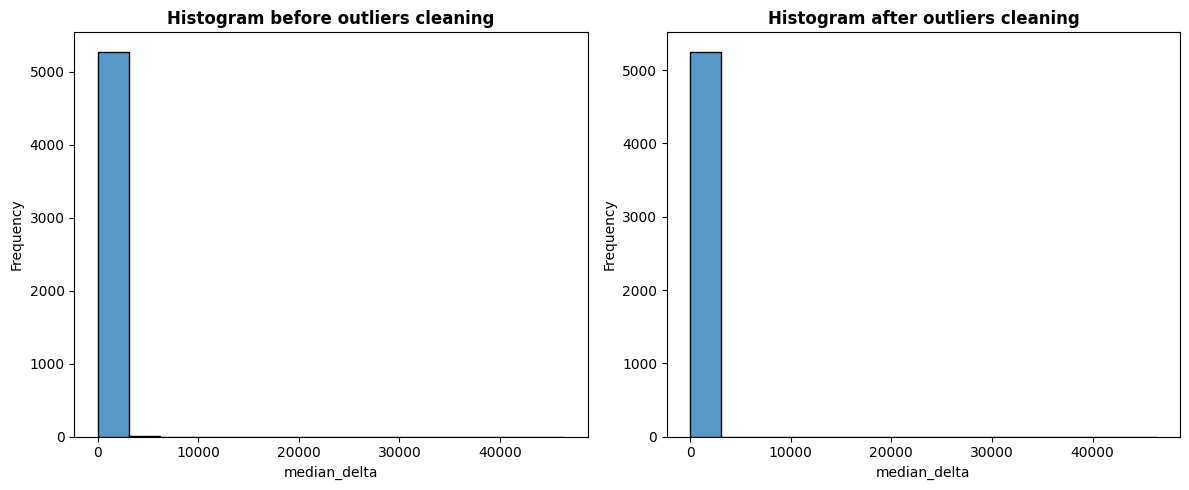

In [550]:
compare_distributions_consistent(races, cleaned_races_df, "median_delta")

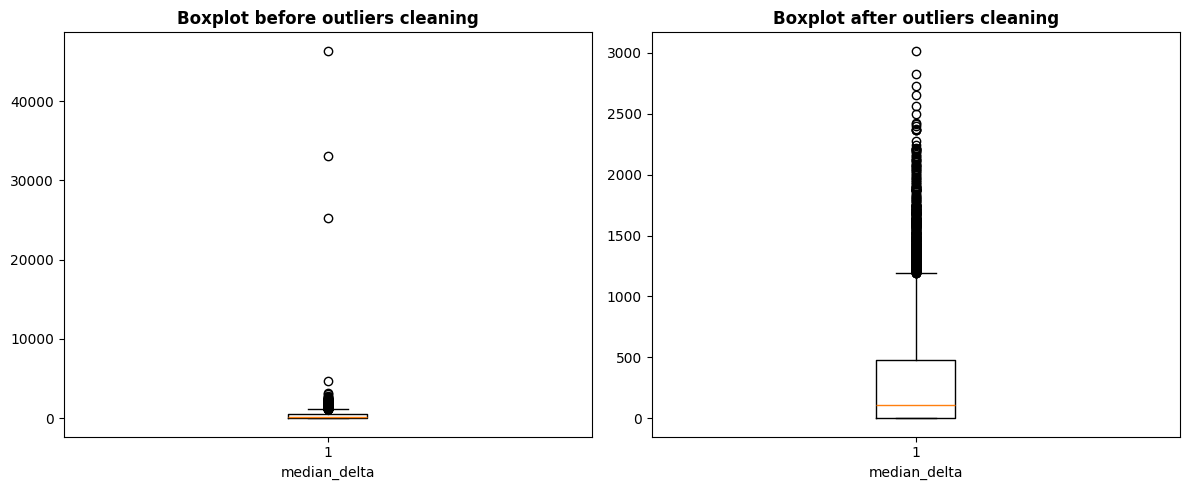

In [551]:
compare_box_plots(races, cleaned_races_df, "median_delta")

After removing the most extreme outliers, we can observe a significant change in the boxplot. Previously, the extreme values heavily skewed the visualization, making it difficult to interpret the majority of the data. Now, with the extreme outliers removed, the boxplot provides a clearer view of the distribution. Importantly, while the visualization has been adjusted, the distribution itself has not been significantly altered.

#### startlist_quality (260)

In [552]:
bound = calculate_outlier_bounds(races, "startlist_quality")
lower_bound_startlist= bound['lower']
upper_bound_startlist = bound['upper']

In [553]:
print(lower_bound_startlist)
print(upper_bound_startlist)

120.0
1792.0


In [554]:
analyze_outliers(races, "startlist_quality", lower_bound_startlist, upper_bound_startlist, 15, 1, 20, 50)

Outliers above upper bound (1792.0): 259
Outliers below lower bound (120.0): 1
Total outliers: 260
Number of outliers in the range of [1792.0, 1812.0]: 21
Number of outliers in the range of [1812.0, 1832.0]: 45
Number of outliers in the range of [1832.0, 1852.0]: 21
Number of outliers in the range of [1852.0, 1872.0]: 19
Number of outliers in the range of [1872.0, 1892.0]: 45
Number of outliers in the range of [1892.0, 1912.0]: 0
Number of outliers in the range of [1912.0, 1932.0]: 0
Number of outliers in the range of [1932.0, 1952.0]: 44
Number of outliers in the range of [1952.0, 1972.0]: 21
Number of outliers in the range of [1972.0, 1992.0]: 0
Number of outliers in the range of [1992.0, 2012.0]: 22
Number of outliers in the range of [2012.0, 2032.0]: 0
Number of outliers in the range of [2032.0, 2052.0]: 21
Number of outliers in the range of [2052.0, 2072.0]: 0
Number of outliers in the range of [2072.0, 2092.0]: 0
Number of outliers > 2092.0: 0

Number of outliers in the range of 

Given that the outliers are fairly evenly distributed, there aren’t any outliers that stand out as more extreme than the others. Therefore, it could be reasonable to keep them all without removing any.

#### length (749)

In [555]:
bound = calculate_outlier_bounds(races, "length")
lower_bound_length= bound['lower']
upper_bound_length = bound['upper']

In [556]:
print(lower_bound_length)
print(upper_bound_length)

64250.0
290250.0


Since we need to account for multiple intervals, we execute analyze_outliers twice: once for the most extreme low-end outliers and once for the most extreme high-end outliers.

In [557]:
# high-end outliers
analyze_outliers(races, "length", lower_bound_length, upper_bound_length, 20, 0, 1000, 0)

Outliers above upper bound (290250.0): 45
Outliers below lower bound (64250.0): 704
Total outliers: 749
Number of outliers in the range of [290250.0, 291250.0]: 3
Number of outliers in the range of [291250.0, 292250.0]: 1
Number of outliers in the range of [292250.0, 293250.0]: 4
Number of outliers in the range of [293250.0, 294250.0]: 24
Number of outliers in the range of [294250.0, 295250.0]: 0
Number of outliers in the range of [295250.0, 296250.0]: 0
Number of outliers in the range of [296250.0, 297250.0]: 2
Number of outliers in the range of [297250.0, 298250.0]: 5
Number of outliers in the range of [298250.0, 299250.0]: 2
Number of outliers in the range of [299250.0, 300250.0]: 0
Number of outliers in the range of [300250.0, 301250.0]: 1
Number of outliers in the range of [301250.0, 302250.0]: 0
Number of outliers in the range of [302250.0, 303250.0]: 0
Number of outliers in the range of [303250.0, 304250.0]: 0
Number of outliers in the range of [304250.0, 305250.0]: 1
Number of 

It is not easy to establish which ones are considered more extreme, but let's try to consider those few that go beyond _299250_

In [558]:
# low-end outliers
analyze_outliers(races, "length", lower_bound_length, upper_bound_length, 0, 26, 0, 4000)

Outliers above upper bound (290250.0): 45
Outliers below lower bound (64250.0): 704
Total outliers: 749
Number of outliers > 290250.0: 45

Number of outliers in the range of [60250.0, 64250.0]: 12
Number of outliers in the range of [56250.0, 60250.0]: 15
Number of outliers in the range of [52250.0, 56250.0]: 19
Number of outliers in the range of [48250.0, 52250.0]: 16
Number of outliers in the range of [44250.0, 48250.0]: 25
Number of outliers in the range of [40250.0, 44250.0]: 29
Number of outliers in the range of [36250.0, 40250.0]: 39
Number of outliers in the range of [32250.0, 36250.0]: 36
Number of outliers in the range of [28250.0, 32250.0]: 40
Number of outliers in the range of [24250.0, 28250.0]: 38
Number of outliers in the range of [20250.0, 24250.0]: 42
Number of outliers in the range of [16250.0, 20250.0]: 62
Number of outliers in the range of [12250.0, 16250.0]: 50
Number of outliers in the range of [8250.0, 12250.0]: 86
Number of outliers in the range of [4250.0, 8250.0

Given that the low-end outliers below the lower bound are fairly evenly distributed, none of them stand out as significantly more extreme than the others. Therefore, it could be reasonable to retain them all.

So, we will focus on removing only the few considered extreme above the upper bound. Before we supposed to consider those above 299250 as extreme outliers, it corresponds approximately the 0.9992 quantile.

In [559]:
upper_extreme_quantile = races["length"].quantile(0.9992)
upper_extreme_quantile

np.float64(299000.0)

In [560]:
len_before_cleaning = len(cleaned_races_df)
cleaned_races_df = cleaned_races_df[(cleaned_races_df['length'] <= upper_extreme_quantile)]

print(f"Remaining rows after removal: {len(cleaned_races_df)}")
print(f"Removed rows: {len_before_cleaning - len(cleaned_races_df)}")

Remaining rows after removal: 5250
Removed rows: 4


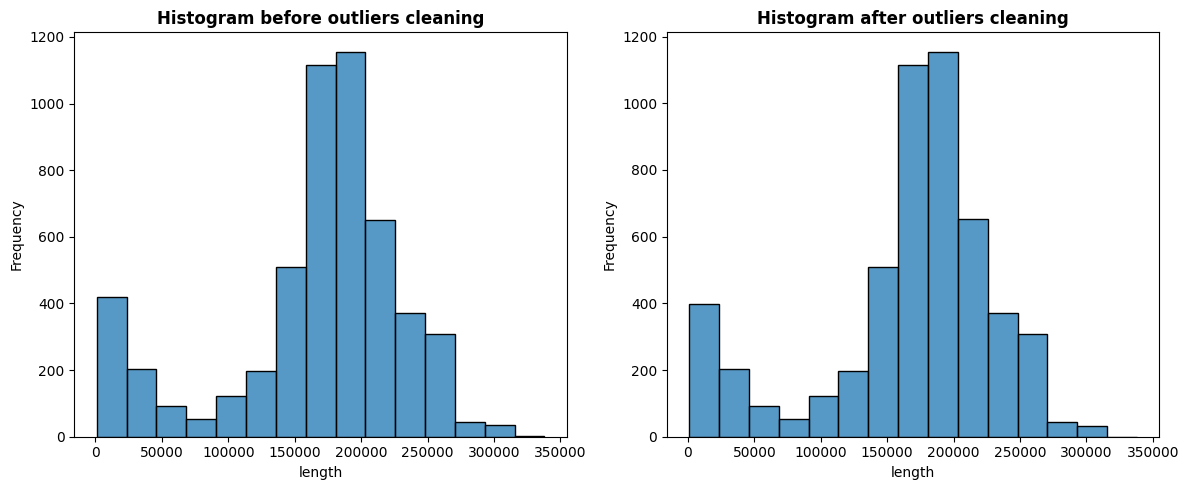

In [561]:
compare_distributions_consistent(races, cleaned_races_df, "length")

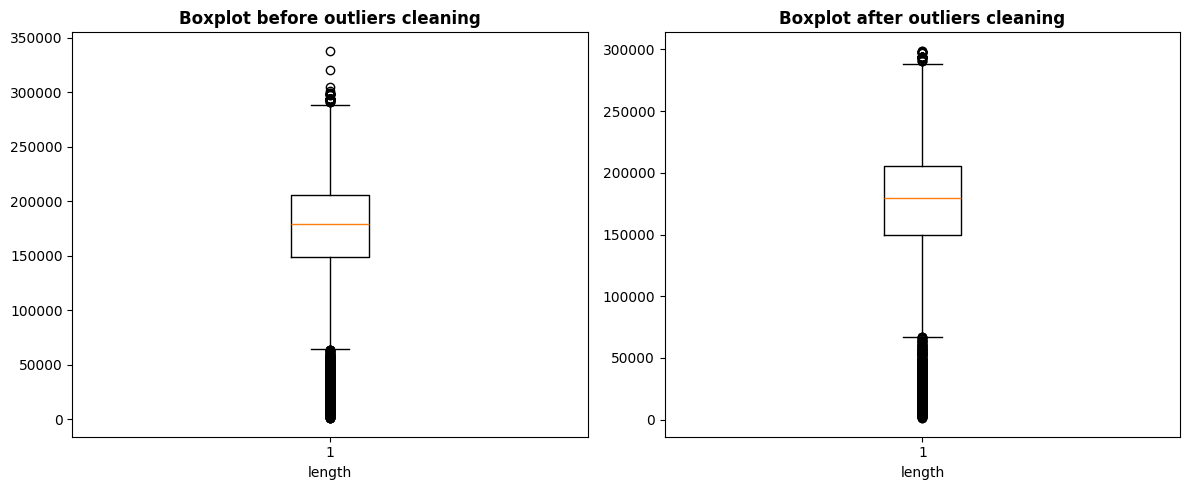

In [562]:
compare_box_plots(races, cleaned_races_df, "length")

As expected, removing only 4 outliers does not impact the distribution or the box plot in any meaningful way.

In [563]:
cleaned_races_df.shape

(5250, 16)

In [564]:
# cleaned_races_df.to_csv("../../dataset/preprocessedRaces_without_outliers.csv", index=False)